**Justifikasi:**

Mengimpor dan mendeklarasikan pustaka fundamental untuk perancangan LSTM, yang terkenal dengan manajemen *memory state* berjangka panjangnya.

In [32]:
from pathlib import Path
import json, random, sys, time
import os

os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=-1"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/local/cuda-12.5"
os.environ['TF_XLA_ENABLE_XLA_DEVICES'] = 'false' # Mematikan XLA devices

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

projectRoot = Path.cwd().resolve()
if projectRoot.name == "notebook":
    projectRoot = projectRoot.parents[1]
if str(projectRoot) not in sys.path:
    sys.path.insert(0, str(projectRoot))

from src.wajib.lstm.LSTM import buildLSTMKeras, trainLSTMKeras, trainLSTMDataset, LSTMScratch
from src.wajib.shared.layers import EmbeddingLayer, DenseLayer
from src.wajib.shared.preprocessing import (
    loadFlickr8kCaptions, buildVocabulary, saveVocabulary, loadVocabulary,
 )
from src.wajib.shared.decoder import greedyDecode
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

import tensorflow as tf
tf.config.optimizer.set_jit(False)

seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print("GPU terdeteksi:", gpus)


GPU terdeteksi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Justifikasi:**

Menyiapkan variabel lintasan menuju file indeks korpus anotasi Flickr8k yang spesifik dan esensial dalam menghubungkan citra dengan teks aslinya.

In [2]:
featuresNpy = projectRoot / "src/wajib/weights/features/flickr8k_features.npy"
featuresIdx = projectRoot / "src/wajib/weights/features/flickr8k_index.json"
captionsFile = projectRoot / "data/flickr8k/captions.txt"
vocabPath = projectRoot / "src/wajib/weights/vocab.json"
weightsDir = projectRoot / "src/wajib/weights/lstm"
weightsDir.mkdir(parents=True, exist_ok=True)

embedDim = 256
maxLen = 30
epochs = 20
batchSize = 64
cnnFeatDim = 2048

variations = [
    (1, 128),
    (1, 512),
    (2, 128),
    (2, 512),
    (3, 128),
    (3, 512),
]


**Justifikasi:**

Sama halnya dengan RNN, langkah ini memuat matriks fitur citra hasil representasi CNN ke dalam memori untuk proses percepatan baca-tulis (I/O).

In [3]:
features_matrix = np.load(featuresNpy)
with open(featuresIdx) as f:
    idx_names = json.load(f)

imageFeatures = {name: features_matrix[i] for i, name in enumerate(idx_names)}
print(f"Loaded {len(imageFeatures)} features, dim={features_matrix.shape[1]}")

captionsDict = loadFlickr8kCaptions(str(captionsFile))

allImages = list(captionsDict.keys())
random.shuffle(allImages)

trainImgs = set(allImages[:6000])
valImgs   = set(allImages[6000:7000])
testImgs  = set(allImages[7000:])

trainCaps = {k: v for k, v in captionsDict.items() if k in trainImgs}
valCaps   = {k: v for k, v in captionsDict.items() if k in valImgs}
testCaps  = {k: v for k, v in captionsDict.items() if k in testImgs}

print(f"Split => train={len(trainCaps)}, val={len(valCaps)}, test={len(testCaps)}")

if vocabPath.exists():
    vocab = loadVocabulary(str(vocabPath))
    print(f"Vocab loaded: {len(vocab)}")
else:
    all_train_caps = [cap for caps in trainCaps.values() for cap in caps]
    vocab = buildVocabulary(all_train_caps, min_freq=2)
    saveVocabulary(vocab, str(vocabPath))
    print(f"Vocab built + saved: {len(vocab)}")


Loaded 8091 features, dim=2048
Split => train=6000, val=1000, test=1091
Vocab loaded: 4558


**Justifikasi:**

Mengeksekusi *Data Loader* khusus LSTM untuk menjembatani token masukan, label urutan berikutnya, dan fitur visual secara bersamaan menggunakan skema *sliding window* atau *sequence pad*.

In [4]:
xCnnTrain, xTokTrain, yTrain = trainLSTMDataset(imageFeatures, trainCaps, vocab, maxLen)
xCnnVal, xTokVal, yVal = trainLSTMDataset(imageFeatures, valCaps, vocab, maxLen)

print(f"Data latih -> xCnn={xCnnTrain.shape}, xTok={xTokTrain.shape}, y={yTrain.shape}")
print(f"Data validasi -> xCnn={xCnnVal.shape}, xTok={xTokVal.shape}, y={yVal.shape}")

histories = {}
for numLayers, hiddenDim in variations:
    name = f"lstm_{numLayers}L_{hiddenDim}h"
    savePath = weightsDir / f"{name}.keras"

    print(f"\n{'='*50}\n  {name}\n{'='*50}")

    model = buildLSTMKeras(
        vocabSize=len(vocab),
        embedDim=embedDim,
        hiddenDim=hiddenDim,
        numLstmLayers=numLayers,
        cnnFeatureDim=cnnFeatDim,
    )
    model.summary()

    hist = trainLSTMKeras(
        model,
        xCnnTrain, xTokTrain, yTrain,
        xCnnVal, xTokVal, yVal,
        epochs=epochs,
        batchSize=batchSize,
        savePath=str(savePath),
    )
    histories[name] = hist
    print(f"  Tersimpan ke {savePath.name}")

print(f"\nSemua {len(variations)} variasi selesai.")


Data latih -> xCnn=(30000, 2048), xTok=(30000, 30), y=(30000, 31)
Data validasi -> xCnn=(5000, 2048), xTok=(5000, 30), y=(5000, 31)

  lstm_1L_128h


I0000 00:00:1778921914.629115    1010 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1751 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_feature         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 256)       │    524,544 │ cnn_feature[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 1, 256)    │          0 │ cnn_proj[0][0]    │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │  1,166,848 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None, 256) │          0 │ expand_dims[0][0… │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_0 (LSTM)       │ (None, None, 128) │    197,120 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, None,      │    587,982 │ lstm_0[0][0]      │
│                     │ 4558)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,476,494 (9.45 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_feature         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 256)       │    524,544 │ cnn_feature[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_5       │ (None, 1, 256)    │          0 │ cnn_proj[0][0]    │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │  1,166,848 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, None, 256) │          0 │ expand_dims_5[0]… │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_0 (LSTM)       │ (None, None, 512) │  1,574,912 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_0 (Dropout) │ (None, None, 512) │          0 │ lstm_0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, None, 512) │  2,099,200 │ dropout_0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, None, 512) │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, None, 512) │  2,099,200 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, None,      │  2,338,254 │ lstm_2[0][0]      │
│                     │ 4558)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,802,958 (37.40 MB)

 Trainable params: 9,802,958 (37.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 122ms/step - loss: 5.0891 - val_loss: 4.7639
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 115ms/step - loss: 4.6752 - val_loss: 4.5697
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 117ms/step - loss: 4.5254 - val_loss: 4.4679
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 117ms/step - loss: 4.4260 - val_loss: 4.3898
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 114ms/step - loss: 4.2866 - val_loss: 4.2157
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 118ms/step - loss: 4.1209 - val_loss: 4.1095
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 114ms/step - loss: 3.9804 - val_loss: 3.9949
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 119ms/step - loss: 3.8370 - val_loss: 3.9055
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 118ms/step - loss: 3.7127 - val_loss: 3.8465
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 112ms/step - loss: 3.6094 - val_loss: 3.8124
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 118ms/step - loss: 3.5135 - val_loss: 3.7889
Epoch 12/20
469/469

**Justifikasi:**

Menggambar metrik kerugian komparatif, di mana plot garis ini dipakai untuk mengevaluasi apakah pergerakan konvergensi *loss* pelatihan berjalan wajar tanpa anomali yang signifikan.

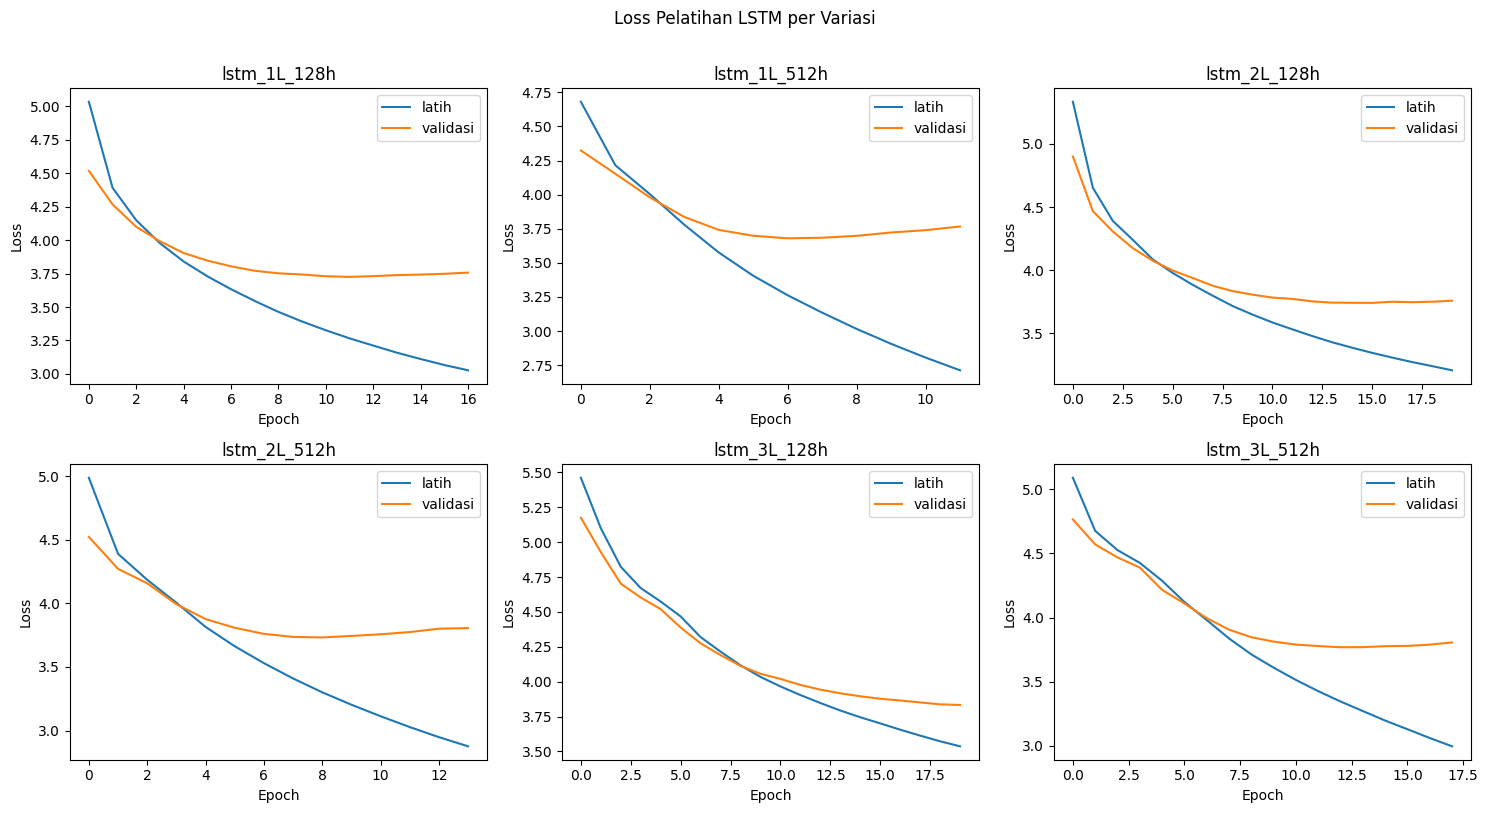

Model                  Val Loss Terbaik   Epoch
-----------------------------------------------
lstm_1L_128h                     3.7251      17
lstm_1L_512h                     3.6799      12
lstm_2L_128h                     3.7412      20
lstm_2L_512h                     3.7316      14
lstm_3L_128h                     3.8324      20
lstm_3L_512h                     3.7684      18

Model terbaik: lstm_1L_512h (layer=1, hidden=512)


In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (name, hist) in zip(axes.flatten(), histories.items()):
    ax.plot(hist['loss'], label='latih')
    ax.plot(hist['val_loss'], label='validasi')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle("Loss Pelatihan LSTM per Variasi", y=1.01)
plt.tight_layout()
plt.savefig(weightsDir / "lstm_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"{'Model':<22} {'Val Loss Terbaik':>16} {'Epoch':>7}")
print('-' * 47)
for name, hist in histories.items():
    print(f"{name:<22} {min(hist['val_loss']):>16.4f} {len(hist['val_loss']):>7}")

bestName = min(histories, key=lambda n: min(histories[n]['val_loss']))
bestLayers = int(bestName.split('L')[0].split('_')[1])
bestHidden = int(bestName.split('h')[0].split('_')[2])
print(f"\nModel terbaik: {bestName} (layer={bestLayers}, hidden={bestHidden})")


**Justifikasi:**

Membangun utilitas penting untuk memigrasikan status gerbang (*gates*: Input, Forget, Output, Cell) dari Keras LSTM ke arsitektur sel kustom *from scratch* yang diracik sendiri.

In [28]:
def loadScratchFromKeras(modelPath, numLayers):
    model = tf.keras.models.load_model(str(modelPath))

    embedLayer = EmbeddingLayer()
    embedLayer.loadWeights(model.get_layer('embedding'))

    projLayer = DenseLayer()
    projLayer.loadWeights(model.get_layer('cnn_proj'))

    outLayer = DenseLayer(activation='softmax')
    outLayer.loadWeights(model.get_layer('output'))

    lstmModel = LSTMScratch()
    lstmModel.loadWeights([model.get_layer(f'lstm_{i}') for i in range(numLayers)])

    return lstmModel, projLayer, embedLayer, outLayer

bestPath = weightsDir / f"{bestName}.keras"
lstmModel, projLayer, embedLayer, outLayer = loadScratchFromKeras(bestPath, bestLayers)

print("Contoh prediksi dari model LSTM terbaik:")
print("=" * 60)
for img in list(valCaps.keys())[:3]:
    feat = imageFeatures[img]
    caption = ' '.join(greedyDecode(lstmModel, projLayer, embedLayer, outLayer, feat, vocab))
    gt = valCaps[img][0]
    print(f"Ground truth : {gt}")
    print(f"Prediksi     : {caption}")
    print()


Contoh prediksi dari model LSTM terbaik:
Ground truth : a black dog leaps over a log
Prediksi     : dog in

Ground truth : a man uses ice picks and crampons to scale ice
Prediksi     : boy down slope snow

Ground truth : a man and a baby are in a yellow kayak on water
Prediksi     : man a is a and boat a



**Justifikasi:**

Mengeksekusi serangkaian eksperimen *hyperparameter tuning* (jumlah layer dan filter) LSTM. Ini merupakan proses *trial-and-error* terstruktur untuk mencari varian LSTM berakurasi maksimum.

In [33]:
results = {}

for numLayers, hiddenDim in variations:
    name = f"lstm_{numLayers}L_{hiddenDim}h"
    path = weightsDir / f"{name}.keras"
    lstmModel, projLayer, embedLayer, outLayer = loadScratchFromKeras(path, numLayers)

    bleuScores = []
    startTime = time.time()

    for img, caps in testCaps.items():
        if img not in imageFeatures:
            continue
        hyp = greedyDecode(lstmModel, projLayer, embedLayer, outLayer, imageFeatures[img], vocab, maxLen)
        refs = [cap.split() for cap in caps]
        
        smooth = SmoothingFunction().method1
        bleuScores.append(sentence_bleu(refs, hyp, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth))

    elapsed = time.time() - startTime
    results[name] = {
        'bleu4': np.mean(bleuScores),
        'time_s': elapsed,
        'layers': numLayers,
        'hidden': hiddenDim,
    }
    print(f"{name:<22}  BLEU-4={results[name]['bleu4']:.4f}  waktu={elapsed:.1f}s")


lstm_1L_128h            BLEU-4=0.0451  waktu=21.8s
lstm_1L_512h            BLEU-4=0.0419  waktu=90.9s
lstm_2L_128h            BLEU-4=0.0419  waktu=30.1s
lstm_2L_512h            BLEU-4=0.0423  waktu=175.6s
lstm_3L_128h            BLEU-4=0.0398  waktu=40.5s
lstm_3L_512h            BLEU-4=0.0421  waktu=202.6s


**Justifikasi:**

Tahap konklusi pencarian model: Sistem secara sekuensial mengambil metrik *validation loss* paling rendah untuk menentukan varian LSTM absolut terbaik yang siap dipadukan dengan modul CNN.

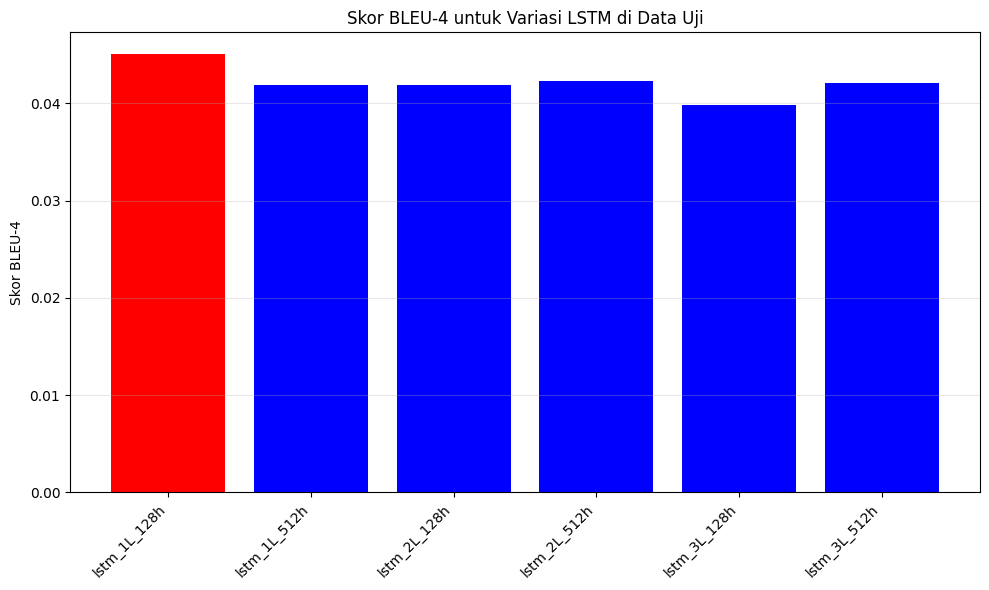


Ringkasan BLEU-4 LSTM:
Model                      BLEU-4  Waktu (detik)
--------------------------------------------------
lstm_1L_128h               0.0451           21.8
lstm_2L_512h               0.0423          175.6
lstm_3L_512h               0.0421          202.6
lstm_1L_512h               0.0419           90.9
lstm_2L_128h               0.0419           30.1
lstm_3L_128h               0.0398           40.5

Terbaik (BLEU-4 data uji): lstm_1L_128h
  BLEU-4=0.0451


In [34]:
bestTestModel = max(results, key=lambda n: results[n]['bleu4'])

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
models = sorted(results.keys())
bleus = [results[m]['bleu4'] for m in models]
colors = ['red' if m == bestTestModel else 'blue' for m in models]

ax.bar(range(len(models)), bleus, color=colors)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel('Skor BLEU-4')
ax.set_title('Skor BLEU-4 untuk Variasi LSTM di Data Uji')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(weightsDir / "lstm_bleu4_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print("Ringkasan BLEU-4 LSTM:")
print(f"{'='*60}")
print(f"{'Model':<22} {'BLEU-4':>10} {'Waktu (detik)':>14}")
print('-' * 50)
for model in sorted(results.keys(), key=lambda m: results[m]['bleu4'], reverse=True):
    print(f"{model:<22} {results[model]['bleu4']:>10.4f} {results[model]['time_s']:>14.1f}")

print(f"\nTerbaik (BLEU-4 data uji): {bestTestModel}")
print(f"  BLEU-4={results[bestTestModel]['bleu4']:.4f}")
